# # ExtraTrees Model for Ethereum Fraud Detection
#
# This notebook implements the **ExtraTrees (Extremely Randomized Trees)** algorithm.
# It is similar to Random Forest but introduces more randomness in split selection,
# often reducing overfitting and training faster.


Data Loaded. Shape: (13920, 24)
Training ExtraTrees Model...
✅ Training Complete.

--- 📊 ExtraTrees Performance ---
Accuracy:  0.9267
Precision: 0.9184
Recall:    0.9194
F1 Score:  0.9189
ROC-AUC:   0.9819
------------------------------


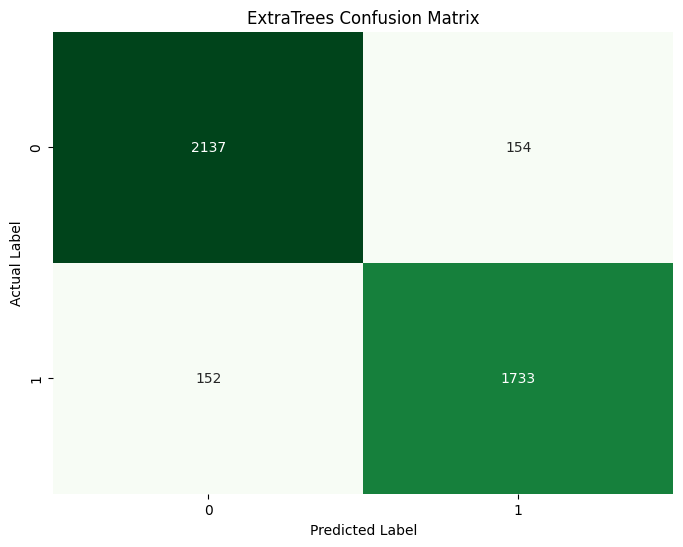

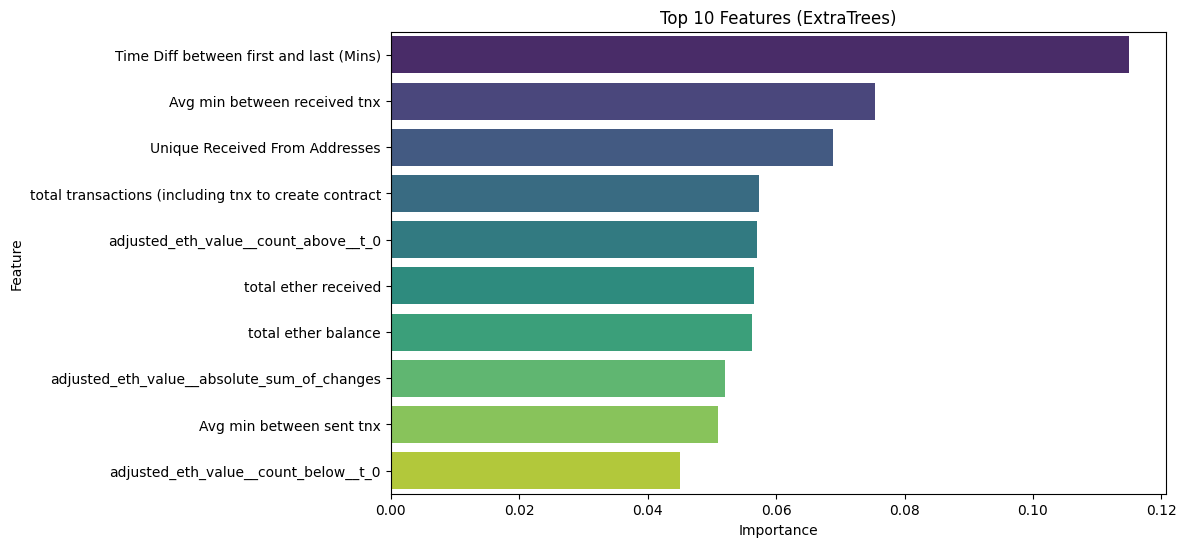

✅ Model saved successfully at: ../models/extratrees_model.pkl
✅ Scaler saved successfully at: ../models/scaler_extratrees.pkl


In [4]:

# %%
# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import ExtraTreesClassifier # <--- The Star of the Show
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)

# %%
# 2. LOAD DATA
# We use the Time-Series version of the dataset
file_path = '../Data/address_data_combined_ts.csv'
df = pd.read_csv(file_path)

print(f"Data Loaded. Shape: {df.shape}")

# %%
# 3. DATA PREPROCESSING
cols_to_drop = ['Address', 'FLAG']
if 'Unnamed: 0' in df.columns:
    cols_to_drop.append('Unnamed: 0')

X = df.drop(columns=cols_to_drop)
y = df['FLAG']

# Split Data (70% Train, 30% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# %%
# 4. FEATURE ENGINEERING (Log Transform)
columns_to_log = [
    'Avg min between sent tnx', 'Avg min between received tnx',
    'Time Diff between first and last (Mins)', 'Unique Received From Addresses',
    'min value received', 'max value received ', 'avg val received',
    'min val sent', 'avg val sent',
    'total transactions (including tnx to create contract',
    'total ether received', 'total ether balance',
    'adjusted_eth_value__absolute_sum_of_changes',
    'adjusted_eth_value__mean_abs_change',
    'adjusted_eth_value__energy_ratio_by_chunks__num_segments_10__segment_focus_0',
    'adjusted_eth_value__sum_values', 'adjusted_eth_value__abs_energy',
    'adjusted_eth_value__ratio_value_number_to_time_series_length',
    'adjusted_eth_value__quantile__q_0.1', 'adjusted_eth_value__count_below__t_0',
    'adjusted_eth_value__count_above__t_0', 'adjusted_eth_value__median'
]

for c in columns_to_log:
    if c in X_train.columns:
        X_train[c] = X_train[c].apply(lambda x: np.log(x) if x > 0 else 0)
        X_test[c] = X_test[c].apply(lambda x: np.log(x) if x > 0 else 0)

# %%
# 5. SCALING
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# %%
# 6. TRAIN EXTRATREES MODEL
# These parameters are generally good for ExtraTrees
et_params = {
    'n_estimators': 1000,
    'max_depth': 20,
    'min_samples_leaf': 2,
    'bootstrap': False,
    'n_jobs': -1,
    'random_state': 42
}

print("Training ExtraTrees Model...")
et_model = ExtraTreesClassifier(**et_params)
et_model.fit(X_train_scaled, y_train)
print("✅ Training Complete.")

# %%
# 7. EVALUATION
y_pred = et_model.predict(X_test_scaled)
y_pred_proba = et_model.predict_proba(X_test_scaled)[:, 1]

# Calculate Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n--- 📊 ExtraTrees Performance ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print("-" * 30)

# %%
# 8. VISUALIZE CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('ExtraTrees Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# %%
# 9. FEATURE IMPORTANCE (Optional)
# See what ExtraTrees thinks is important (often different from XGBoost!)
importance = et_model.feature_importances_
feature_names = X.columns

fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
fi_df = fi_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=fi_df, palette='viridis', legend=False)
plt.title('Top 10 Features (ExtraTrees)')
plt.show()

